In [1]:
# ── Installations (Google Colab) ────────────────────────────────────────────
!pip install textblob wordcloud --quiet
import nltk
nltk.download('punkt',                       quiet=True)
nltk.download('punkt_tab',                   quiet=True)
nltk.download('stopwords',                   quiet=True)
nltk.download('averaged_perceptron_tagger',  quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet',                     quiet=True)
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'], capture_output=True)
print("Installation terminée ✓")


Installation terminée ✓


In [2]:
# ── Upload du dataset (amazon_review.csv) ───────────────────────────────────
from google.colab import files
uploaded = files.upload()   # Sélectionner : amazon_review.csv


Saving amazon_review.csv to amazon_review.csv


In [3]:
# ── Imports & chargement ────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import re
from collections import Counter

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

from textblob import TextBlob
from wordcloud import WordCloud

# Chargement
df = pd.read_csv("amazon_review.csv")
print(f"Dataset chargé : {df.shape[0]} avis produits")
df.head()


Dataset chargé : 1000 avis produits


,review_id,category,rating,review
0,1,Books,2,Terrible product. Broke after two days of use....
1,2,Kitchen,4,Excellent quality and fast delivery. Very sati...
2,3,Sports,4,Excellent quality and fast delivery. Very sati...
3,4,Toys,1,Horrible product. Instructions are unclear and...
4,5,Sports,1,Poor quality and extremely overpriced. I regre...


## Tâche 1 : Analyse de sentiment

Classification de chaque avis en **positif**, **négatif** ou **neutre**
via la polarité TextBlob, puis bar chart de la distribution.


Distribution des sentiments :
 sentiment
positive    723
negative    185
neutral      92
Name: count, dtype: int64


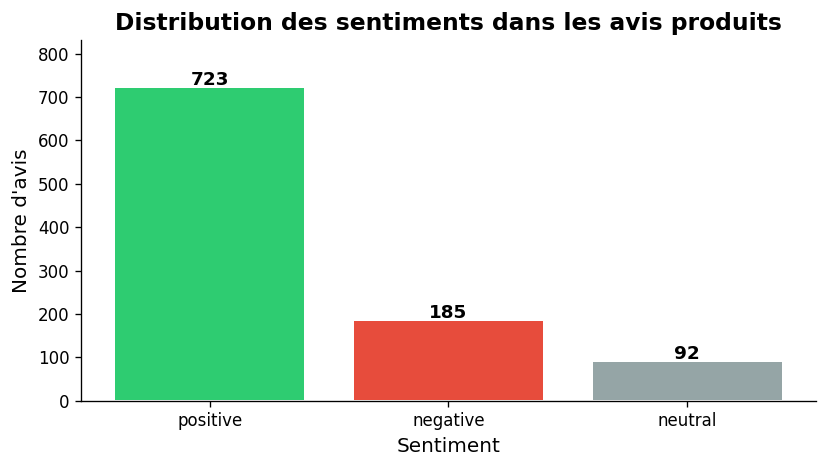

In [4]:
# Task 1 : Sentiment Analysis

def classify_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        return 'positive'
    elif polarity < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['review'].apply(classify_sentiment)
sentiment_counts = df['sentiment'].value_counts()
print("Distribution des sentiments :\n", sentiment_counts)

colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
              color=[colors[s] for s in sentiment_counts.index],
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold', fontsize=11)
ax.set_title("Distribution des sentiments dans les avis produits", fontsize=14, fontweight='bold')
ax.set_xlabel("Sentiment", fontsize=12)
ax.set_ylabel("Nombre d'avis", fontsize=12)
ax.set_ylim(0, sentiment_counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Tâche 2 : Prétraitement et lemmatisation

Pipeline complet : minuscules → suppression ponctuation/chiffres
→ filtrage stopwords → POS tagging → lemmatisation WordNet.


In [5]:
# Task 2 : Text Preprocessing & Lemmatization

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Convertit le POS tag TreeBank en format WordNet."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_and_lemmatize(text):
    text   = str(text).lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]

df['lemmas'] = df['review'].apply(preprocess_and_lemmatize)
print("Prétraitement terminé.")
print(f"Exemple — Original  : {df['review'].iloc[0][:80]}...")
print(f"Exemple — Lemmes    : {df['lemmas'].iloc[0][:15]}")


Prétraitement terminé.
Exemple — Original  : Terrible product. Broke after two days of use. Complete waste of money. Really....
Exemple — Lemmes    : ['terrible', 'product', 'break', 'two', 'day', 'use', 'complete', 'waste', 'money', 'really']


## Tâche 3 : Top 15 des mots les plus fréquents

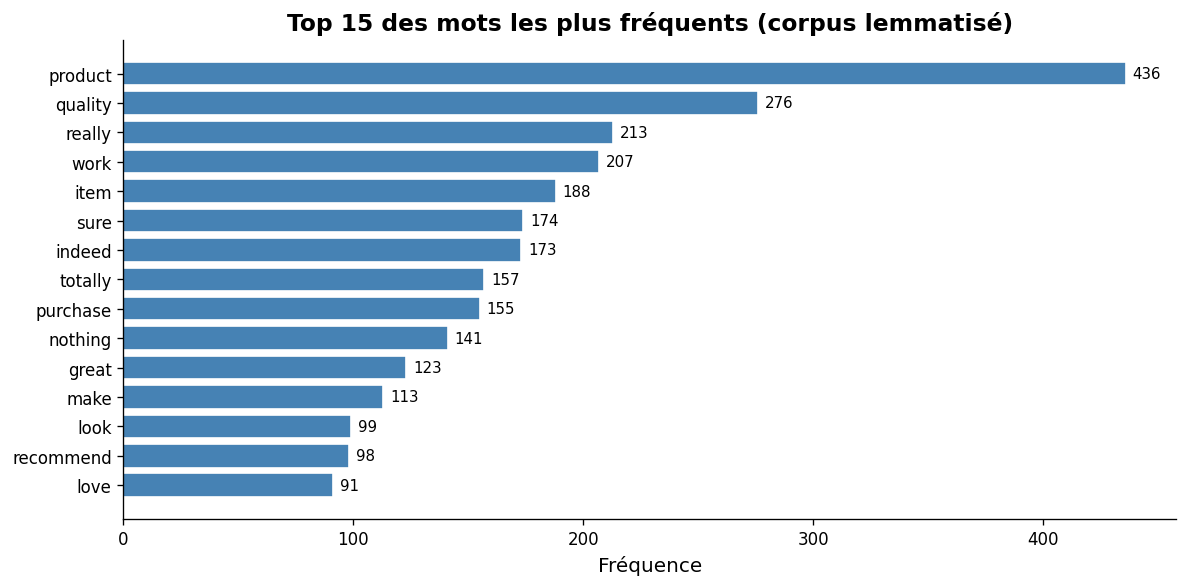

In [6]:
# Task 3 : Word Frequency – Top 15

all_lemmas = [w for lemma_list in df['lemmas'] for w in lemma_list]
freq       = Counter(all_lemmas)
top15      = freq.most_common(15)
words15, counts15 = zip(*top15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(reversed(words15)), list(reversed(counts15)),
               color='steelblue', edgecolor='white')
for bar, val in zip(bars, reversed(counts15)):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_title("Top 15 des mots les plus fréquents (corpus lemmatisé)", fontsize=14, fontweight='bold')
ax.set_xlabel("Fréquence", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Tâche 4 : Word Cloud

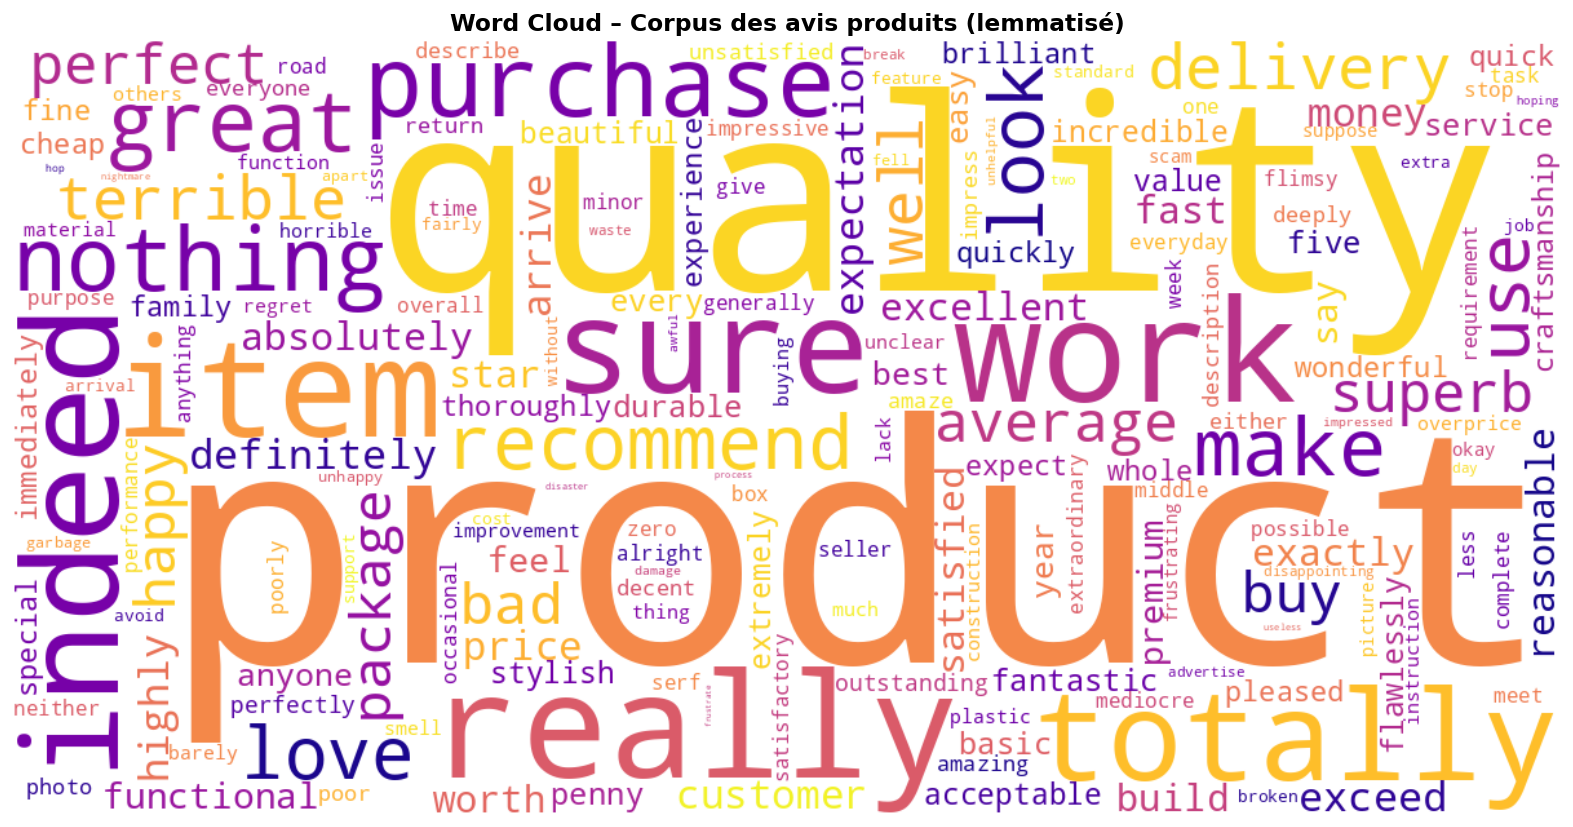

In [7]:
# Task 4 : Word Cloud

corpus_text = ' '.join(all_lemmas)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='plasma',
    max_words=200,
    collocations=False,
    prefer_horizontal=0.8,
)
wc.generate(corpus_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title("Word Cloud – Corpus des avis produits (lemmatisé)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Tâche 5 : Fréquence des noms, verbes et adjectifs

Fréquences POS :
  Noms (NN)            : 2,842
  Verbes (VB)          : 1,186
  Adjectifs (JJ)       : 2,068


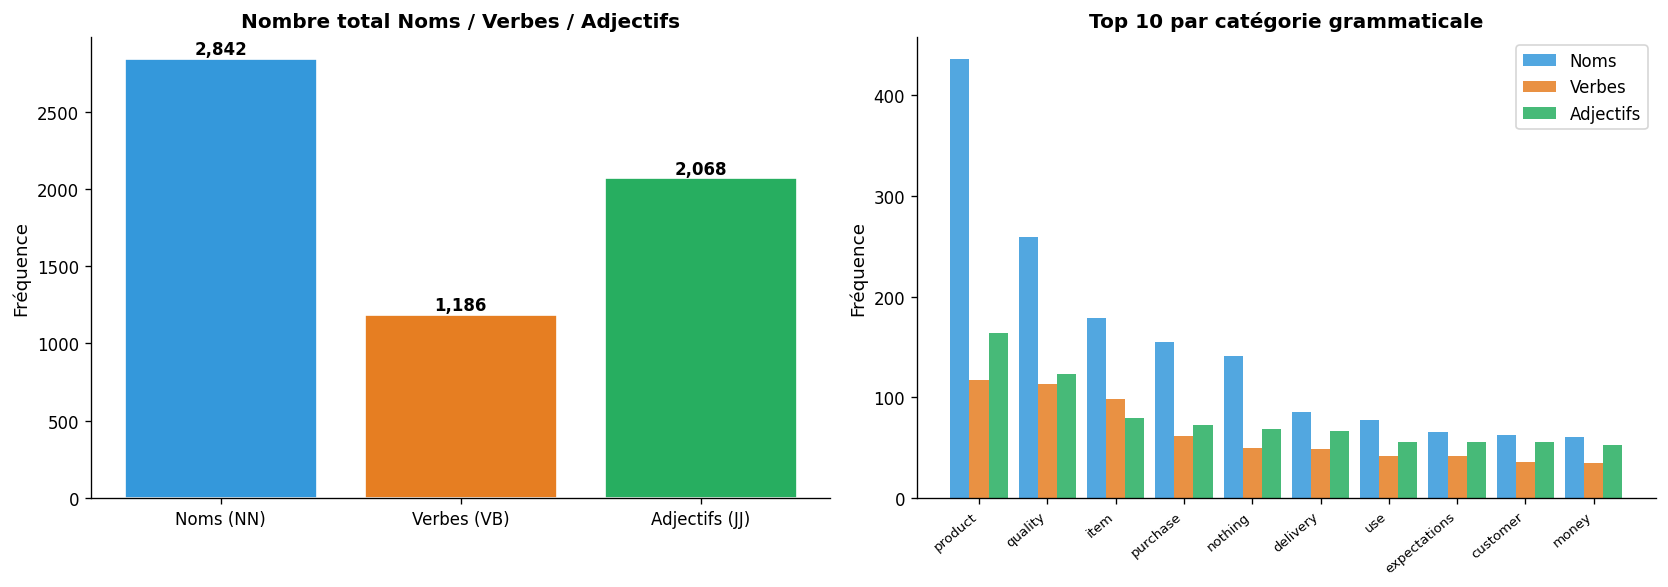

In [8]:
# Task 5 : POS Frequency (Nouns, Verbs, Adjectives)

all_raw_tokens = []
for review in df['review']:
    text   = str(review).lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    all_raw_tokens.extend(tokens)

all_pos_tags = pos_tag(all_raw_tokens)
nouns = [w for w, t in all_pos_tags if t.startswith('NN')]
verbs = [w for w, t in all_pos_tags if t.startswith('VB')]
adjs  = [w for w, t in all_pos_tags if t.startswith('JJ')]

pos_counts = {'Noms (NN)': len(nouns), 'Verbes (VB)': len(verbs), 'Adjectifs (JJ)': len(adjs)}
print("Fréquences POS :")
for k, v in pos_counts.items():
    print(f"  {k:<20} : {v:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : totaux
ax1 = axes[0]
bars = ax1.bar(pos_counts.keys(), pos_counts.values(),
               color=['#3498db', '#e67e22', '#27ae60'], edgecolor='white')
for bar, val in zip(bars, pos_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title("Nombre total Noms / Verbes / Adjectifs", fontsize=12, fontweight='bold')
ax1.set_ylabel("Fréquence", fontsize=11)
ax1.spines[['top', 'right']].set_visible(False)

# Graphe 2 : Top 10 groupé
top_n = Counter(nouns).most_common(10)
top_v = Counter(verbs).most_common(10)
top_a = Counter(adjs).most_common(10)

ax2  = axes[1]
x    = range(10)
w    = 0.28
ax2.bar([i - w for i in x], [c for _, c in top_n], width=w, label='Noms',      color='#3498db', alpha=0.85)
ax2.bar([i     for i in x], [c for _, c in top_v], width=w, label='Verbes',    color='#e67e22', alpha=0.85)
ax2.bar([i + w for i in x], [c for _, c in top_a], width=w, label='Adjectifs', color='#27ae60', alpha=0.85)
ax2.set_title("Top 10 par catégorie grammaticale", fontsize=12, fontweight='bold')
ax2.set_xticks(list(x))
ax2.set_xticklabels([w for w, _ in top_n], rotation=40, ha='right', fontsize=8)
ax2.legend()
ax2.set_ylabel("Fréquence", fontsize=11)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
